<a href="https://colab.research.google.com/github/shadowalvan/OPT810S_Group_Assignment/blob/main/OPT_Group_Assignment_Question_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 4: Stochastic Gradient Descent

## Group Information

**Group:** A  
**Random Seed:** 10

Seed 10 will be used in all stochastic gradient descent experiments to ensure that the results are reproducible.

In [6]:
!pip install -q --no-deps d2l==1.0.3

### Exercise 4.1

Experiment with different learning-rate schedules for stochastic gradient descent and with different numbers of iterations. In particular, plot the distance from the optimal solution $(0,0)$ as a function of the number of iterations.

**[10 Marks]**

epoch 50, x1: -0.137953, x2: 0.086476
epoch 50, x1: -0.043230, x2: 0.053364
epoch 50, x1: -0.347580, x2: 0.028353
epoch 50, x1: -0.041250, x2: 0.047926
epoch 50, x1: -0.137953, x2: 0.086476


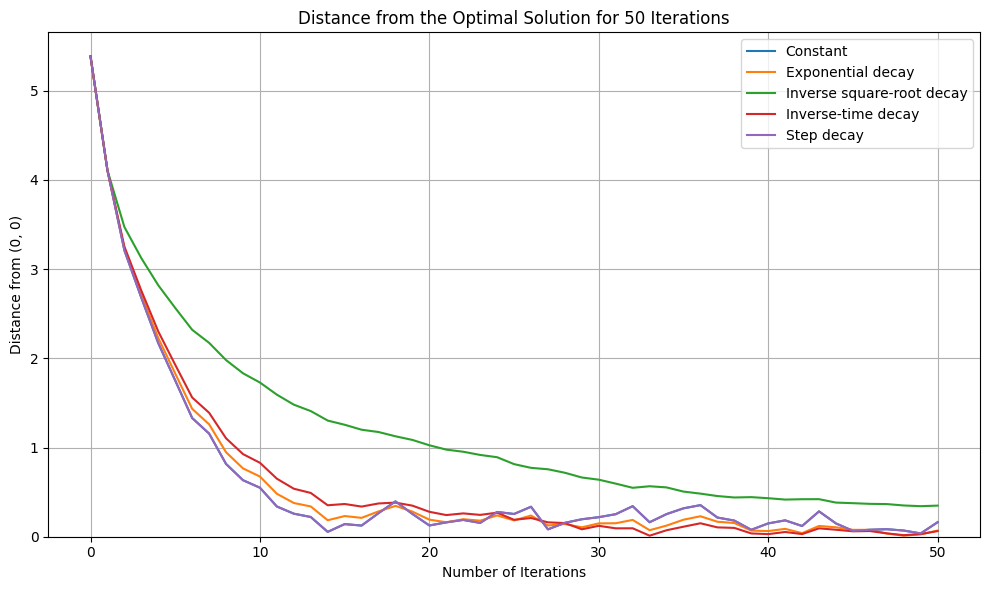

epoch 100, x1: 0.109694, x2: -0.010816
epoch 100, x1: 0.130587, x2: -0.023666
epoch 100, x1: -0.014069, x2: -0.018391
epoch 100, x1: 0.128438, x2: -0.021517
epoch 100, x1: 0.147101, x2: -0.003217


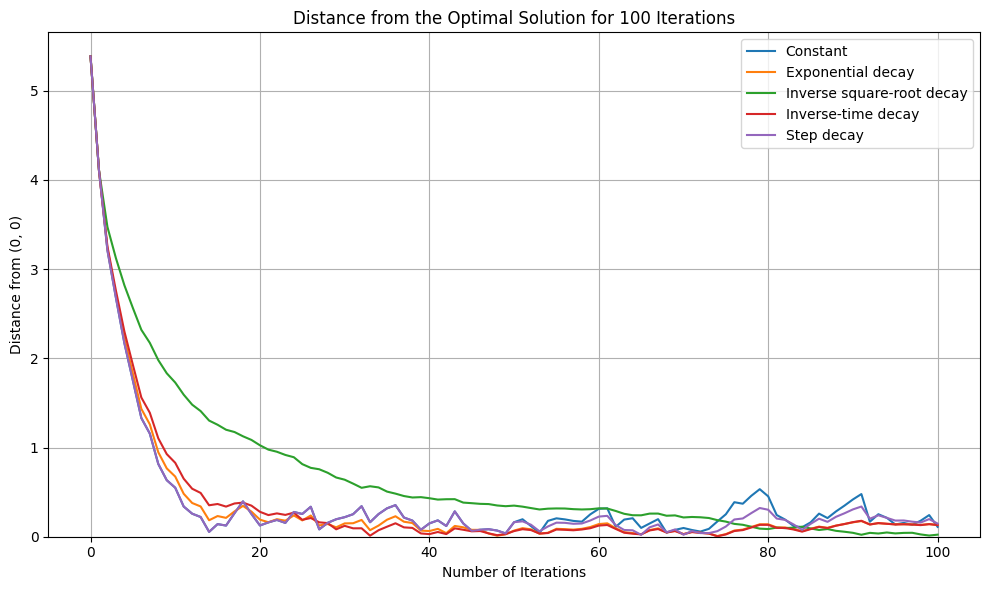

epoch 200, x1: 0.319263, x2: 0.135825
epoch 200, x1: 0.060465, x2: -0.000005
epoch 200, x1: 0.045269, x2: 0.017160
epoch 200, x1: 0.070722, x2: 0.024881
epoch 200, x1: 0.072245, x2: 0.035133


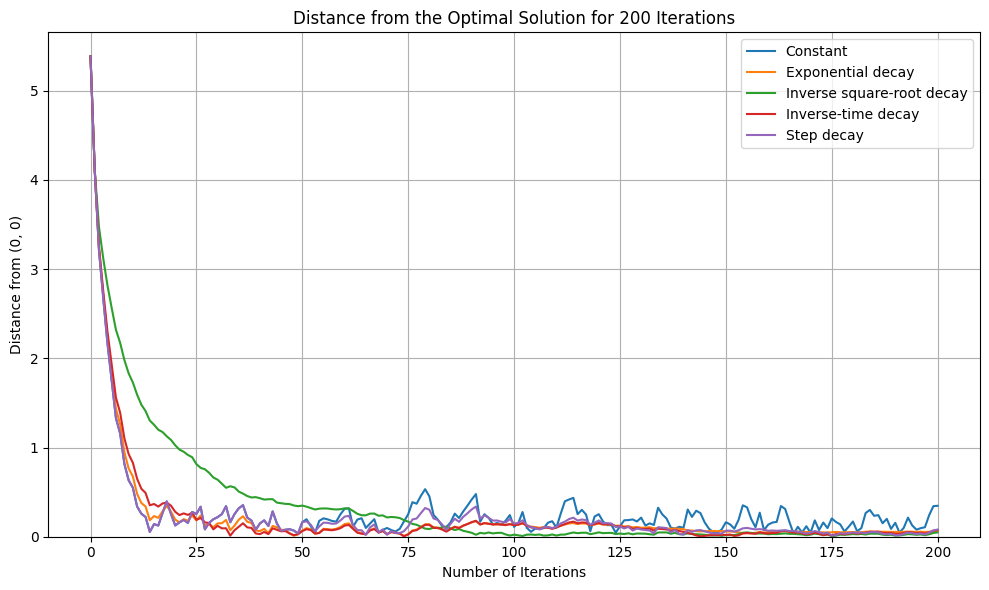

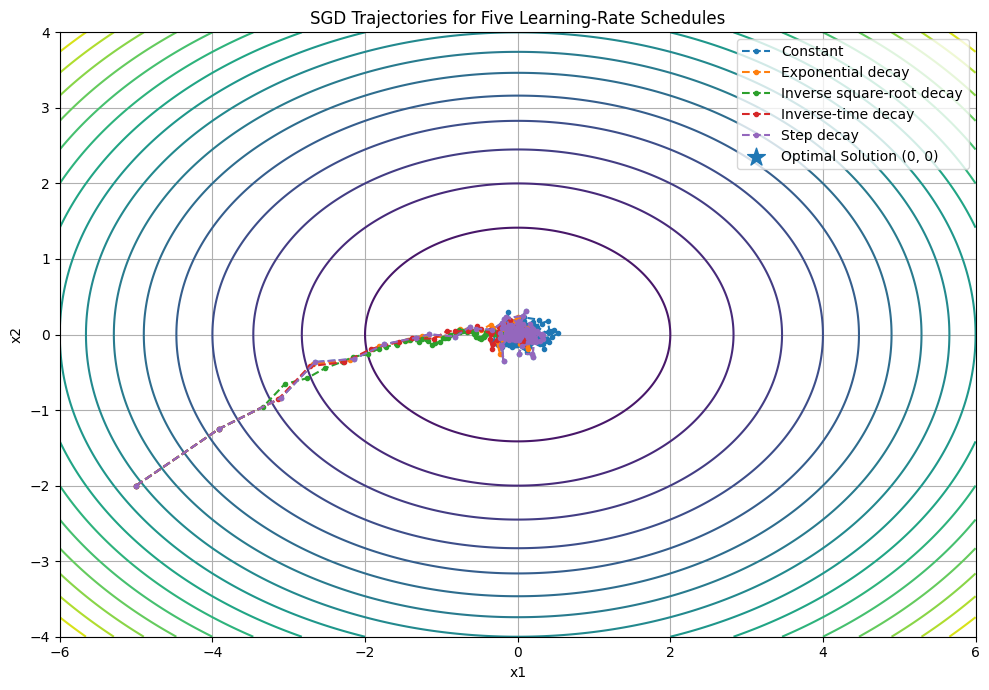

SGD Results
-----------------------------------------------------------------------------------------------
Iterations     Learning-Rate Schedule                  Final Distance      Minimum Distance    
-----------------------------------------------------------------------------------------------
50             Constant                                0.162816            0.036956            
50             Exponential decay                       0.068677            0.011626            
50             Inverse square-root decay               0.348735            0.342279            
50             Inverse-time decay                      0.063233            0.011745            
50             Step decay                              0.162816            0.036956            
100            Constant                                0.110226            0.036956            
100            Exponential decay                       0.132714            0.007390            
100            Inverse squar

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from d2l import tensorflow as d2l

# Set the group's random seed
tf.random.set_seed(10)


# Calculate the objective function value
def objective_function(first_coordinate, second_coordinate):
    return first_coordinate ** 2 + 2 * second_coordinate ** 2


# Calculate the gradient of the objective function
def objective_gradient(first_coordinate, second_coordinate):
    return 2 * first_coordinate, 4 * second_coordinate


# Set the base learning rate
base_learning_rate = 0.1

# Store the current learning-rate schedule
current_learning_rate_schedule = None

# Store the current iteration number
current_iteration = 0


# Perform one stochastic gradient descent update
def stochastic_gradient_descent(
    first_coordinate,
    second_coordinate,
    first_state,
    second_state,
    gradient_function
):
    global current_iteration

    first_gradient, second_gradient = gradient_function(
        first_coordinate,
        second_coordinate
    )

    # Add random noise to simulate a stochastic gradient
    first_gradient += tf.random.normal([], mean=0.0, stddev=1.0)
    second_gradient += tf.random.normal([], mean=0.0, stddev=1.0)

    learning_rate = (
        base_learning_rate
        * current_learning_rate_schedule()
    )

    current_iteration += 1

    updated_first_coordinate = (
        first_coordinate
        - learning_rate * first_gradient
    )

    updated_second_coordinate = (
        second_coordinate
        - learning_rate * second_gradient
    )

    return (
        updated_first_coordinate,
        updated_second_coordinate,
        0,
        0
    )


# Keep the learning rate unchanged
def constant_learning_rate():
    return 1.0


# Reduce the learning rate exponentially
def exponential_learning_rate():
    return 0.98 ** current_iteration


# Reduce the learning rate using the inverse square root
def inverse_square_root_learning_rate():
    return 1 / math.sqrt(current_iteration + 1)


# Reduce the learning rate using inverse-time decay
def inverse_time_learning_rate():
    decay_rate = 0.05

    return 1 / (
        1 + decay_rate * current_iteration
    )


# Reduce the learning rate after every 50 iterations
def step_decay_learning_rate():
    decay_factor = 0.5
    decay_interval = 50

    number_of_completed_intervals = (
        current_iteration // decay_interval
    )

    return decay_factor ** number_of_completed_intervals


# Run SGD using one learning-rate schedule
def run_stochastic_gradient_descent(
    learning_rate_schedule,
    number_of_steps
):
    global current_learning_rate_schedule
    global current_iteration

    # Use the same random noise for every schedule
    tf.random.set_seed(10)

    current_learning_rate_schedule = learning_rate_schedule
    current_iteration = 0

    trajectory = d2l.train_2d(
        stochastic_gradient_descent,
        steps=number_of_steps,
        f_grad=objective_gradient
    )

    distances_from_optimum = []

    for first_coordinate, second_coordinate in trajectory:
        distance = math.sqrt(
            float(first_coordinate) ** 2
            + float(second_coordinate) ** 2
        )

        distances_from_optimum.append(distance)

    return trajectory, distances_from_optimum


# Define the five learning-rate schedules
learning_rate_schedules = {
    "Constant": constant_learning_rate,
    "Exponential decay": exponential_learning_rate,
    "Inverse square-root decay": inverse_square_root_learning_rate,
    "Inverse-time decay": inverse_time_learning_rate,
    "Step decay": step_decay_learning_rate
}

# Compare different iteration counts
iteration_counts = [50, 100, 200]

experiment_results = []
final_trajectories = {}


# Run every schedule for every iteration count
for number_of_steps in iteration_counts:
    plt.figure(figsize=(10, 6))

    for schedule_name, schedule_function in learning_rate_schedules.items():
        trajectory, distances = run_stochastic_gradient_descent(
            schedule_function,
            number_of_steps
        )

        experiment_results.append(
            {
                "number_of_steps": number_of_steps,
                "schedule_name": schedule_name,
                "final_distance": distances[-1],
                "minimum_distance": min(distances)
            }
        )

        if number_of_steps == 200:
            final_trajectories[schedule_name] = trajectory

        plt.plot(
            range(len(distances)),
            distances,
            label=schedule_name
        )

    plt.xlabel("Number of Iterations")
    plt.ylabel("Distance from (0, 0)")
    plt.title(
        f"Distance from the Optimal Solution for "
        f"{number_of_steps} Iterations"
    )
    plt.ylim(bottom=0)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Create the contour coordinates
first_coordinate_values = np.linspace(-6, 6, 400)
second_coordinate_values = np.linspace(-4, 4, 400)

first_coordinate_grid, second_coordinate_grid = np.meshgrid(
    first_coordinate_values,
    second_coordinate_values
)

objective_values = objective_function(
    first_coordinate_grid,
    second_coordinate_grid
)


# Plot the SGD trajectories on the contour graph
plt.figure(figsize=(10, 7))

plt.contour(
    first_coordinate_grid,
    second_coordinate_grid,
    objective_values,
    levels=20
)

for schedule_name, trajectory in final_trajectories.items():
    first_coordinate_history = [
        float(point[0])
        for point in trajectory
    ]

    second_coordinate_history = [
        float(point[1])
        for point in trajectory
    ]

    plt.plot(
        first_coordinate_history,
        second_coordinate_history,
        marker="o",
        markersize=3,
        linestyle="--",
        label=schedule_name
    )

plt.scatter(
    0,
    0,
    marker="*",
    s=180,
    label="Optimal Solution (0, 0)"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title(
    "SGD Trajectories for Five Learning-Rate Schedules"
)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Display the experiment results
print("SGD Results")
print("-" * 95)

print(
    f"{'Iterations':<15}"
    f"{'Learning-Rate Schedule':<40}"
    f"{'Final Distance':<20}"
    f"{'Minimum Distance':<20}"
)

print("-" * 95)

for result in experiment_results:
    print(
        f"{result['number_of_steps']:<15}"
        f"{result['schedule_name']:<40}"
        f"{result['final_distance']:<20.6f}"
        f"{result['minimum_distance']:<20.6f}"
    )

### Exercise 4.2

Prove that for the function $f(x_1,x_2)=x_1^2+2x_2^2$, adding normal noise to the gradient is equivalent to minimizing the loss function $f(\mathbf{x},\mathbf{w})=(x_1-w_1)^2+2(x_2-w_2)^2$, where $\mathbf{x}$ is drawn from a normal distribution.

**[5 Marks]**

In [ ]:
def random_f(x1, x2, w1, w2):  # Random loss function
    return (x1 - w1) ** 2 + 2 * (x2 - w2) ** 2


def random_f_grad(x1, x2, w1, w2):  # Gradient of the random loss
    return 2 * (x1 - w1), 4 * (x2 - w2)


# Reset the seed
tf.random.set_seed(10)

# Select a point for comparing the gradients
x1 = tf.constant(1.5, dtype=tf.float32)
x2 = tf.constant(-0.8, dtype=tf.float32)

# Calculate the original gradient
g1, g2 = f_grad(x1, x2)

# Generate normal noise
noise1 = tf.random.normal([], 0.0, 1)
noise2 = tf.random.normal([], 0.0, 1)

# Add normal noise to the original gradient
noisy_g1 = g1 + noise1
noisy_g2 = g2 + noise2

# Choose w1 and w2 so the gradients are equal
w1 = -noise1 / 2
w2 = -noise2 / 4

# Calculate the gradient of the random loss
random_g1, random_g2 = random_f_grad(
    x1,
    x2,
    w1,
    w2
)

# Display the gradient results
print("Original gradient with normal noise:")
print(f"g1 = {float(noisy_g1):.6f}")
print(f"g2 = {float(noisy_g2):.6f}")

print("\nGradient of the random loss function:")
print(f"g1 = {float(random_g1):.6f}")
print(f"g2 = {float(random_g2):.6f}")

# Check that the gradients are equal
tf.debugging.assert_near(noisy_g1, random_g1)
tf.debugging.assert_near(noisy_g2, random_g2)

print("\nThe two gradients are equal.")


# Number of random samples
number_of_samples = 100000

# Generate normally distributed values of w1 and w2
w1_samples = tf.random.normal(
    [number_of_samples],
    mean=0.0,
    stddev=0.5
)

w2_samples = tf.random.normal(
    [number_of_samples],
    mean=0.0,
    stddev=0.25
)

# Calculate the random loss for all samples
random_loss_values = random_f(
    x1,
    x2,
    w1_samples,
    w2_samples
)

# Estimate the expected random loss
expected_random_loss = tf.reduce_mean(
    random_loss_values
)

# Calculate the original objective function value
original_loss = f(x1, x2)

# The theoretical expected loss is f(x1, x2) + 3/8
theoretical_loss = original_loss + 3 / 8

# Display the loss results
print("\nOriginal objective function value:")
print(f"{float(original_loss):.6f}")

print("\nEstimated expected random loss:")
print(f"{float(expected_random_loss):.6f}")

print("\nTheoretical expected random loss:")
print(f"{float(theoretical_loss):.6f}")


Original gradient with normal noise:
g1 = 2.124219
g2 = -2.716821

Gradient of the random loss function:
g1 = 2.124219
g2 = -2.716821

The two gradients are equal.

Original objective function value:
3.530000

Estimated expected random loss:
3.901000

Theoretical expected random loss:
3.905000


### Exercise 4.3

Compare the convergence of stochastic gradient descent when sampling from $\{(x_1,y_1),(x_2,y_2),\ldots,(x_n,y_n)\}$ with replacement and when sampling without replacement.

**[5 Marks]**

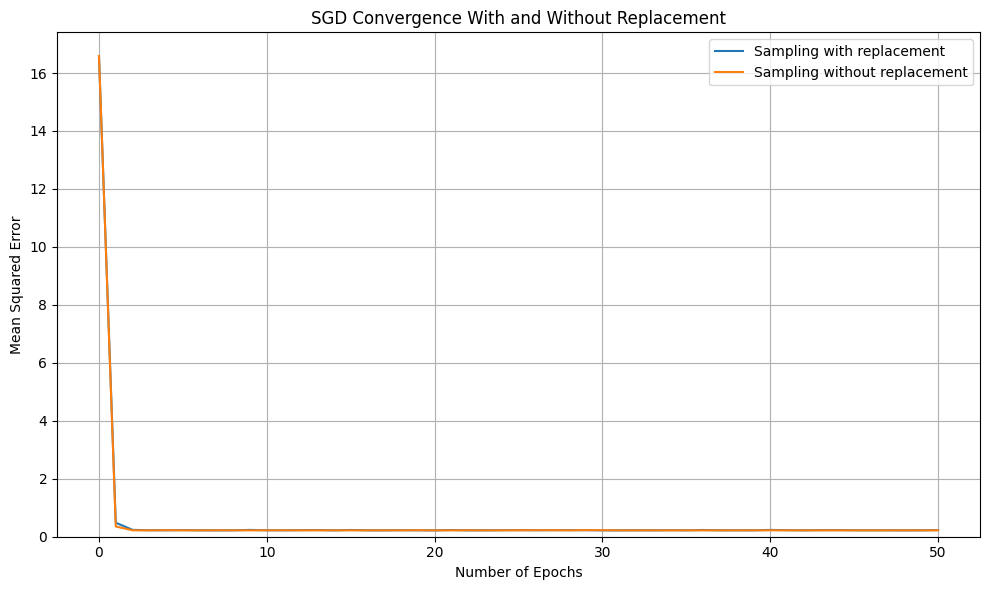

SGD Sampling Results
--------------------------------------------------------------------------------
Sampling Method                    Final MSE      w              b              
--------------------------------------------------------------------------------
With replacement                   0.228986       3.056559       2.093224       
Without replacement                0.220780       3.018214       1.977154       


In [ ]:
# Reset the seed
tf.random.set_seed(10)

# Create a sample dataset
number_of_samples = 100

x_data = tf.linspace(
    -2.0,
    2.0,
    number_of_samples
)

y_data = (
    3 * x_data
    + 2
    + tf.random.normal(
        [number_of_samples],
        0.0,
        0.5
    )
)


def calculate_loss(w, b):
    # Calculate predictions for the complete dataset
    predictions = w * x_data + b

    # Calculate the mean squared error
    return tf.reduce_mean(
        (predictions - y_data) ** 2
    )


def sgd_with_replacement(epochs, learning_rate):
    # Reset the seed
    tf.random.set_seed(10)

    # Initial model parameters
    w = tf.Variable(0.0)
    b = tf.Variable(0.0)

    # Store the loss after each epoch
    loss_history = [
        float(calculate_loss(w, b))
    ]

    for epoch in range(epochs):
        # Select random samples with replacement
        for step in range(number_of_samples):
            index = tf.random.uniform(
                [],
                minval=0,
                maxval=number_of_samples,
                dtype=tf.int32
            )

            x_sample = x_data[index]
            y_sample = y_data[index]

            # Calculate the prediction and error
            prediction = w * x_sample + b
            error = prediction - y_sample

            # Calculate the gradients
            w_grad = 2 * error * x_sample
            b_grad = 2 * error

            # Update the model parameters
            w.assign_sub(
                learning_rate * w_grad
            )

            b.assign_sub(
                learning_rate * b_grad
            )

        # Store the loss after the current epoch
        loss_history.append(
            float(calculate_loss(w, b))
        )

    return loss_history, float(w), float(b)


def sgd_without_replacement(epochs, learning_rate):
    # Reset the seed
    tf.random.set_seed(10)

    # Initial model parameters
    w = tf.Variable(0.0)
    b = tf.Variable(0.0)

    # Store the loss after each epoch
    loss_history = [
        float(calculate_loss(w, b))
    ]

    for epoch in range(epochs):
        # Shuffle the dataset once per epoch
        indices = tf.random.shuffle(
            tf.range(number_of_samples)
        )

        # Use every sample exactly once
        for index in indices:
            x_sample = x_data[index]
            y_sample = y_data[index]

            # Calculate the prediction and error
            prediction = w * x_sample + b
            error = prediction - y_sample

            # Calculate the gradients
            w_grad = 2 * error * x_sample
            b_grad = 2 * error

            # Update the model parameters
            w.assign_sub(
                learning_rate * w_grad
            )

            b.assign_sub(
                learning_rate * b_grad
            )

        # Store the loss after the current epoch
        loss_history.append(
            float(calculate_loss(w, b))
        )

    return loss_history, float(w), float(b)


# Experiment settings
epochs = 50
learning_rate = 0.01

# Run SGD with replacement
with_replacement_loss, with_replacement_w, with_replacement_b = (
    sgd_with_replacement(
        epochs,
        learning_rate
    )
)

# Run SGD without replacement
without_replacement_loss, without_replacement_w, without_replacement_b = (
    sgd_without_replacement(
        epochs,
        learning_rate
    )
)


# Plot the convergence results
plt.figure(figsize=(10, 6))

plt.plot(
    range(epochs + 1),
    with_replacement_loss,
    label="Sampling with replacement"
)

plt.plot(
    range(epochs + 1),
    without_replacement_loss,
    label="Sampling without replacement"
)

# Label and display the graph
plt.xlabel("Number of Epochs")
plt.ylabel("Mean Squared Error")
plt.title(
    "SGD Convergence With and Without Replacement"
)
plt.ylim(bottom=0)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Display the final results
print("SGD Sampling Results")
print("-" * 80)

print(
    f"{'Sampling Method':<35}"
    f"{'Final MSE':<15}"
    f"{'w':<15}"
    f"{'b':<15}"
)

print("-" * 80)

print(
    f"{'With replacement':<35}"
    f"{with_replacement_loss[-1]:<15.6f}"
    f"{with_replacement_w:<15.6f}"
    f"{with_replacement_b:<15.6f}"
)

print(
    f"{'Without replacement':<35}"
    f"{without_replacement_loss[-1]:<15.6f}"
    f"{without_replacement_w:<15.6f}"
    f"{without_replacement_b:<15.6f}"
)


### Exercise 4.4

How would you change the stochastic gradient descent solver if some gradient, or rather some coordinate associated with it, was consistently larger than all the other gradients?

**[5 Marks]**

**Handling Large Gradient Coordinates**
 Using fixed learning rate lead to overshooting for steep dimensions or slow convergence for flatter ones.
 **Adaptive Learning Rate Methods** like Adagrad, RMSprop or Adam which adjust the learning rate for each parameter individually would solve this.

epoch 200, x1: 0.082708, x2: 0.077354


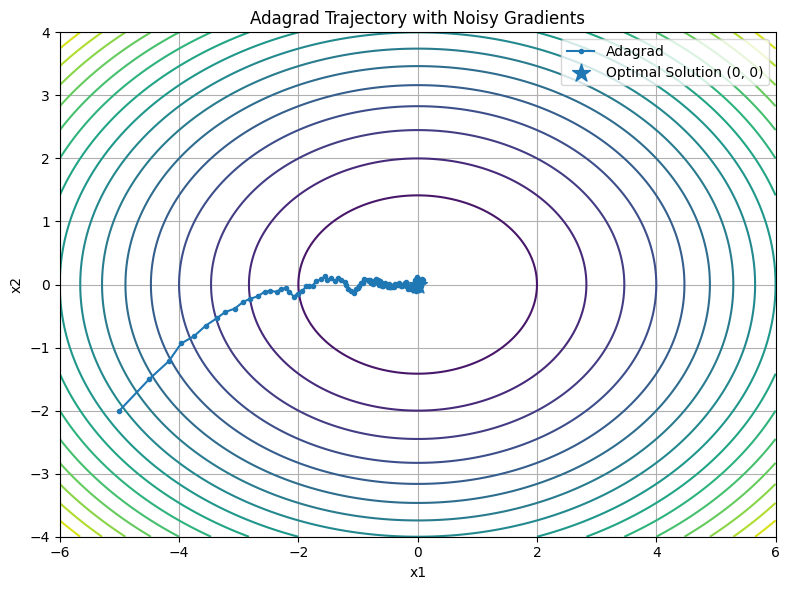

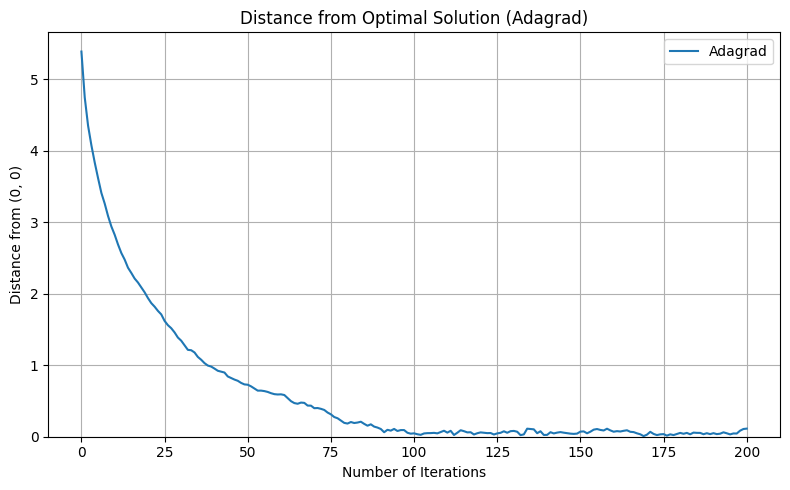

Final distance from optimum (Adagrad): 0.113244


In [10]:
!pip install -q --no-deps d2l==1.0.3
import tensorflow as tf
import matplotlib.pyplot as plt
from d2l import tensorflow as d2l

# Our group's seed
tf.random.set_seed(10)

def f(x1, x2):  # Objective function (same as Ex 4.1)
    return x1 ** 2 + 2 * x2 ** 2

def f_grad(x1, x2):  # Gradient of the objective function
    return 2 * x1, 4 * x2

def adagrad_updater(x1, x2, s1, s2, f_grad): # Now accepts s1 and s2
    # Calculate the gradient
    g1, g2 = f_grad(x1, x2)

    # Simulate noisy gradient (as in Ex 4.1)
    g1 += tf.random.normal([], 0.0, 1)
    g2 += tf.random.normal([], 0.0, 1)

    # Accumulate squared gradients (s1 and s2 are passed in and updated)
    s1_new = s1 + tf.square(g1)
    s2_new = s2 + tf.square(g2)

    # Adaptive learning rate for each parameter
    # Epsilon (1e-8) added for numerical stability as in the example
    eta = 0.5 # Base learning rate as in the example
    x1_new = x1 - eta * g1 / tf.sqrt(s1_new + 1e-8)
    x2_new = x2 - eta * g2 / tf.sqrt(s2_new + 1e-8)

    # Return updated x1, x2, and the new s1, s2 state
    return x1_new, x2_new, s1_new, s2_new

# Run Adagrad and plot the trajectory
# d2l.train_2d will now pass initial s1 and s2 to adagrad_updater (usually default to 0)
trace_adagrad = d2l.train_2d(
    adagrad_updater,
    steps=200,
    f_grad=f_grad
)

# Calculate distances from optimum (0,0)
distances_adagrad = []
for x1, x2 in trace_adagrad:
    # Explicitly cast x1 and x2 to float32 to avoid InvalidArgumentError with tf.sqrt
    distance = tf.sqrt(tf.cast(x1, tf.float32)**2 + tf.cast(x2, tf.float32)**2)
    distances_adagrad.append(distance.numpy())

# --- Plotting ---
# Contour plot (copied from Ex 4.1 for context)
x1_values = tf.linspace(-6.0, 6.0, 400)
x2_values = tf.linspace(-4.0, 4.0, 400)
X1, X2 = tf.meshgrid(x1_values, x2_values)
Z = f(X1, X2)

plt.figure(figsize=(8, 6))
plt.contour(
    X1.numpy(),
    X2.numpy(),
    Z.numpy(),
    levels=20
)

# Plot Adagrad trajectory
x1_history_adagrad = [float(point[0]) for point in trace_adagrad]
x2_history_adagrad = [float(point[1]) for point in trace_adagrad]
plt.plot(
    x1_history_adagrad,
    x2_history_adagrad,
    marker='o',
    markersize=3,
    linestyle='-',
    label='Adagrad'
)

# Mark the optimal solution
plt.scatter(
    0,
    0,
    marker='*',
    s=180,
    label='Optimal Solution (0, 0)'
)

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Adagrad Trajectory with Noisy Gradients')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot distance over iterations
plt.figure(figsize=(8, 5))
plt.plot(
    range(len(distances_adagrad)),
    distances_adagrad,
    label='Adagrad'
)
plt.xlabel('Number of Iterations')
plt.ylabel('Distance from (0, 0)')
plt.title('Distance from Optimal Solution (Adagrad)')
plt.ylim(bottom=0)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final distance from optimum (Adagrad): {distances_adagrad[-1]:.6f}")

### Exercise 4.5

Assume that $f(x)=x^2(1+\sin x)$. How many local minima does $f$ have? Can you change $f$ in such a way that, to minimize it, one needs to evaluate all the local minima?

**[5 Marks]**

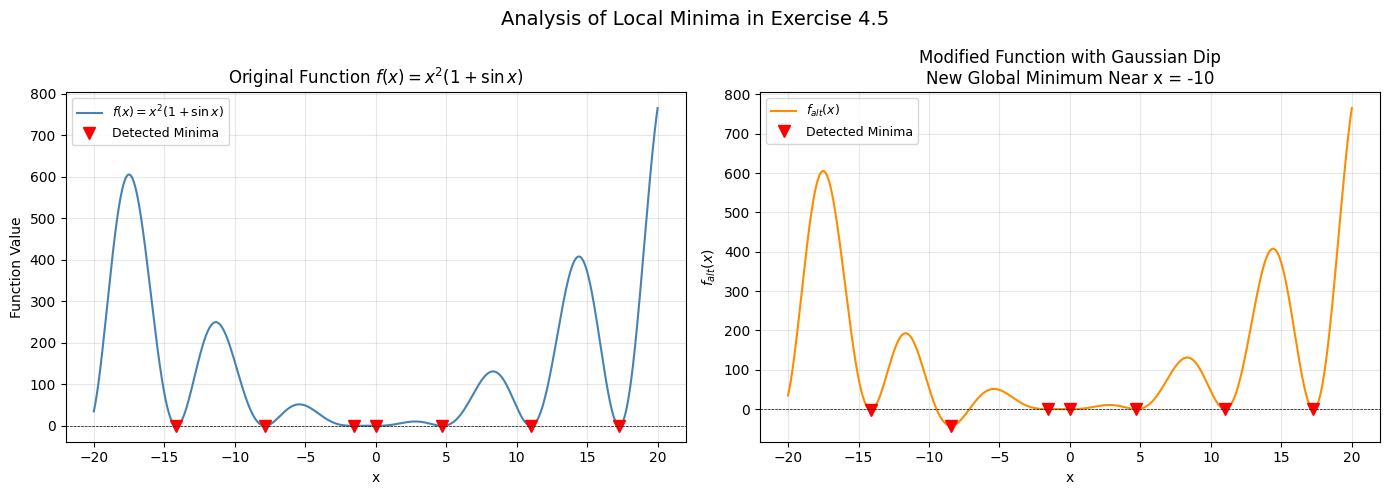

Number of local minima found for f(x) on [-20,20]: 7
  Minimum at x =  -0.0000, f(x) = 0.000000
  Minimum at x =  -1.5708, f(x) = 0.000000
  Minimum at x =   4.7124, f(x) = 0.000000
  Minimum at x =  10.9956, f(x) = 0.000000
  Minimum at x =  -7.8540, f(x) = 0.000000
  Minimum at x = -14.1372, f(x) = 0.000000
  Minimum at x =  17.2788, f(x) = 0.000000

Overall minimum for modified function on [-20,20]:
  x = -8.4433
  f(x) = -42.5371


In [9]:
import numpy as np
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

# Original function
def f45(x):
    return x**2 * (1 + np.sin(x))

# Domain
x_range = np.linspace(-20, 20, 5000)
y_vals = f45(x_range)

# -------------------------------
# Find local minima of original function
# -------------------------------
local_min_x = []

for i in range(1, len(y_vals) - 1):
    if y_vals[i] < y_vals[i - 1] and y_vals[i] < y_vals[i + 1]:

        bound_start = x_range[i - 1]
        bound_end = x_range[i + 1]

        result = minimize_scalar(
            f45,
            bounds=(bound_start, bound_end),
            method='bounded'
        )

        if result.success:
            local_min_x.append((result.x, result.fun))

# Remove duplicate minima
unique_minima = []

for xm, fm in local_min_x:
    if not any(abs(xm - xu) < 0.1 for xu, _ in unique_minima):
        unique_minima.append((xm, fm))

# -------------------------------
# Modified function
# -------------------------------
A_new = 100.0      # amplitude
x0_new = -10.0     # center
sigma_new = 2.0    # width

def f45_modified_alt(x):
    return (
        x**2 * (1 + np.sin(x))
        - A_new * np.exp(-((x - x0_new) / sigma_new) ** 2)
    )

y_mod_alt = f45_modified_alt(x_range)

# -------------------------------
# Find local minima of modified function
# -------------------------------
local_min_x_mod_alt = []

for i in range(1, len(y_mod_alt) - 1):
    if y_mod_alt[i] < y_mod_alt[i - 1] and y_mod_alt[i] < y_mod_alt[i + 1]:

        bound_start = x_range[i - 1]
        bound_end = x_range[i + 1]

        result = minimize_scalar(
            f45_modified_alt,
            bounds=(bound_start, bound_end),
            method='bounded'
        )

        if result.success:
            local_min_x_mod_alt.append((result.x, result.fun))

# Remove duplicate minima
unique_mod_alt = []

for xm, fm in local_min_x_mod_alt:
    if not any(abs(xm - xu) < 0.1 for xu, _ in unique_mod_alt):
        unique_mod_alt.append((xm, fm))

# -------------------------------
# Plotting
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original function plot
axes[0].plot(
    x_range,
    y_vals,
    color='steelblue',
    linewidth=1.5,
    label=r'$f(x)=x^2(1+\sin x)$'
)

for i, (xm, fm) in enumerate(unique_minima):
    axes[0].plot(
        xm,
        fm,
        'rv',
        markersize=8,
        label='Detected Minima' if i == 0 else ""
    )

axes[0].axhline(
    0,
    color='black',
    linewidth=0.5,
    linestyle='--'
)

axes[0].set_title(
    r'Original Function $f(x)=x^2(1+\sin x)$'
)
axes[0].set_xlabel('x')
axes[0].set_ylabel('Function Value')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Modified function plot
axes[1].plot(
    x_range,
    y_mod_alt,
    color='darkorange',
    linewidth=1.5,
    label=r'$f_{alt}(x)$'
)

for i, (xm, fm) in enumerate(unique_mod_alt):
    axes[1].plot(
        xm,
        fm,
        'rv',
        markersize=8,
        label='Detected Minima' if i == 0 else ""
    )

axes[1].axhline(
    0,
    color='black',
    linewidth=0.5,
    linestyle='--'
)

axes[1].set_title(
    f'Modified Function with Gaussian Dip\n'
    f'New Global Minimum Near x = {int(x0_new)}'
)

axes[1].set_xlabel('x')
axes[1].set_ylabel(r'$f_{alt}(x)$')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Overall figure
plt.suptitle(
    'Analysis of Local Minima in Exercise 4.5',
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    'ex4_5_minima_comparison.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# -------------------------------
# Print results
# -------------------------------
print(
    f'Number of local minima found for f(x) on [-20,20]: '
    f'{len(unique_minima)}'
)

for xm, fm in sorted(unique_minima, key=lambda t: t[1]):
    print(
        f'  Minimum at x = {xm:8.4f}, '
        f'f(x) = {fm:.6f}'
    )

if unique_mod_alt:
    global_min_mod_alt = min(
        unique_mod_alt,
        key=lambda t: t[1]
    )

    print(
        f'\nOverall minimum for modified function on [-20,20]:'
    )
    print(
        f'  x = {global_min_mod_alt[0]:.4f}'
    )
    print(
        f'  f(x) = {global_min_mod_alt[1]:.4f}'
    )
else:
    print(
        '\nNo minima detected for modified function.')